In [5]:
import pandas as pd                     # Pandas library
import numpy as np                      # NumPy library
import statsmodels.api as sm            # Statsmodels library   OLS 회귀 사용

In [6]:
df = pd.read_csv("data/auto-mpg.csv")           # 데이터 불러오기
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
# strip -> 앞뒤 공백 제거, lower -> 소문자로 변환, replace(" ", "_") -> 공백 " "을 _로 치환
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# to_numeric -> 컬럼 값을 숫자로 변환, error='coerce' -> 숫자변환이 안되는 값은 NaN으로 처리
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# dropna() -> 결측치가 있는 행을 전부 제거
df = df[['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin']].dropna()

In [8]:
# origin의 type을 범주형으로 변환
df["origin"] = df["origin"].astype("category")

In [9]:
#원 핫 인코딩 수행
df = pd.get_dummies(df, columns=["origin"], prefix="origin")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,True,False,False
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,True,False,False
394,44.0,4,97.0,52.0,2130,24.6,82,False,True,False
395,32.0,4,135.0,84.0,2295,11.6,82,True,False,False
396,28.0,4,120.0,79.0,2625,18.6,82,True,False,False


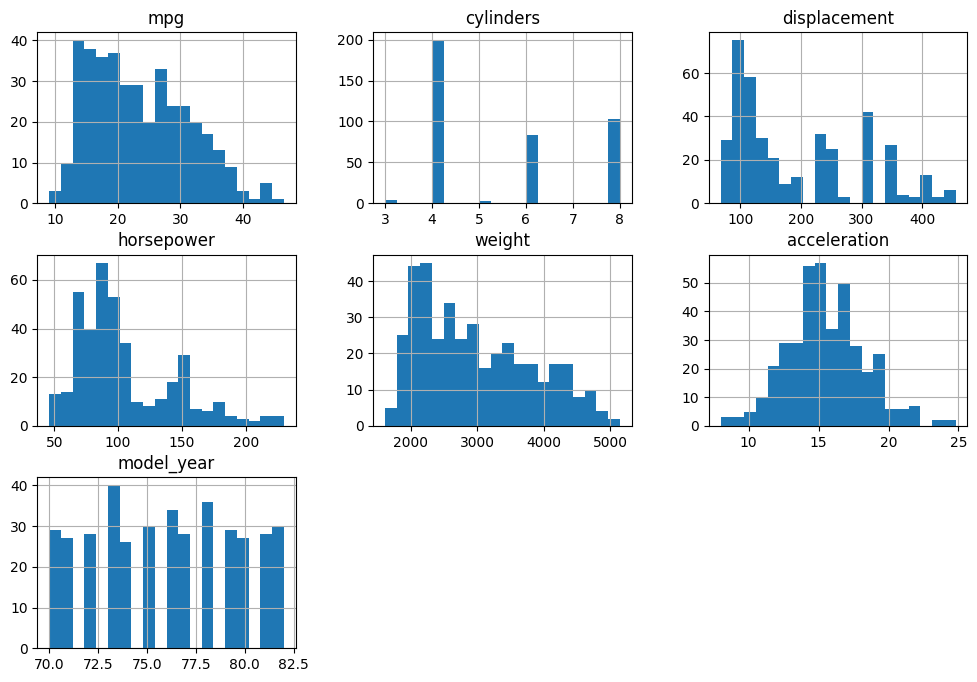

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 모든 수치형 변수 히스토그램
df.hist(bins=20, figsize=(12,8))
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# 독립변수(X), 종속변수(y) 분리
X = df.drop(columns=["mpg"]).astype(float)
y = df["mpg"]

# train/test 나누기 (기본: 75%/25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

In [12]:
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

# 성능 평가
y_pred = model.predict(X_test_sm)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     183.8
Date:                Sun, 12 Oct 2025   Prob (F-statistic):          1.20e-111
Time:                        21:40:25   Log-Likelihood:                -816.67
No. Observations:                 313   AIC:                             1651.
Df Residuals:                     304   BIC:                             1685.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.9786      4.049     -3.205   

In [37]:
df2 = df.copy()

# min-max scaling
for col in ["cylinders", "model_year"]:
    df2[col] = (df2[col] - df2[col].min()) / (df2[col].max() - df2[col].min())

# 로그변환
for col in ["displacement", "horsepower", "weight"]:
    df2[col] = np.log1p(df2[col].clip(lower=0))

# 표준화
tmp = df2["acceleration"]
df2["cylinders"] = (tmp - tmp.mean()) / tmp.std(ddof=0)

In [ ]:
from sklearn.model_selection import train_test_split

# 독립변수(X), 종속변수(y) 분리
X = df2.drop(columns=["mpg"]).astype(float)
y = df2["mpg"]

# train/test 나누기 (기본: 80%/20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

In [39]:
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

# 성능 평가
y_pred = model.predict(X_test_sm)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     255.4
Date:                Thu, 02 Oct 2025   Prob (F-statistic):          1.71e-123
Time:                        01:39:23   Log-Likelihood:                -791.39
No. Observations:                 313   AIC:                             1599.
Df Residuals:                     305   BIC:                             1629.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.3661      0.360     14.905   

In [ ]:
from sklearn.model_selection import train_test_split

# 독립변수(X), 종속변수(y) 분리
X = df.drop(columns=["mpg"]).astype(float)
y = df["mpg"]

# train/test 나누기 (기본: 80%/20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_cols = [c for c in df.columns if c != "mpg"]
X_train = X_train[X_cols].reset_index(drop=True)
X_test  = X_test[X_cols].reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [51]:
# (a) 표준화
X_train_std = (X_train - X_train.mean()) / X_train.std(ddof=0)
X_test_std  = (X_test - X_train.mean()) / X_train.std(ddof=0)
X_train_std.columns = [f"{c}_std" for c in X_cols]
X_test_std.columns  = [f"{c}_std" for c in X_cols]

In [52]:
# (b) 로그 변환 (음수 방지용 clip)
X_train_log = np.log1p(X_train.clip(lower=0))
X_test_log  = np.log1p(X_test.clip(lower=0))
X_train_log.columns = [f"{c}_log" for c in X_cols]
X_test_log.columns  = [f"{c}_log" for c in X_cols]

In [53]:
# (c) Min-Max Scaling
xmin = X_train.min()
xmax = X_train.max()
X_train_mm = (X_train - xmin) / (xmax - xmin).replace(0, np.nan)
X_test_mm  = (X_test - xmin) / (xmax - xmin).replace(0, np.nan)
X_train_mm = X_train_mm.fillna(0.0)
X_test_mm  = X_test_mm.fillna(0.0)
X_train_mm.columns = [f"{c}_mm" for c in X_cols]
X_test_mm.columns  = [f"{c}_mm" for c in X_cols]

In [54]:
# (d) 제곱항(Polynomial features)
X_train_sq = X_train ** 2
X_test_sq  = X_test ** 2
X_train_sq.columns = [f"{c}_sq" for c in X_cols]
X_test_sq.columns  = [f"{c}_sq" for c in X_cols]

In [55]:
X_train_all = pd.concat([X_train,X_train_std.reset_index(drop=True),
                         X_train_log.reset_index(drop=True),
                         X_train_mm.reset_index(drop=True),
                         X_train_sq.reset_index(drop=True)], axis=1)

X_test_all = pd.concat([X_test.reset_index(drop=True),
                        X_test_std.reset_index(drop=True),
                        X_test_log.reset_index(drop=True),
                        X_test_mm.reset_index(drop=True),
                        X_test_sq.reset_index(drop=True)], axis=1)

print("원본 특성 수:", len(X_cols))
print("확장된 특성 수:", X_train_all.shape[1])

# 5) 선형회귀 (statsmodels OLS)
X_train_sm = sm.add_constant(X_train_all)
X_test_sm  = sm.add_constant(X_test_all, has_constant="add")

원본 특성 수: 9
확장된 특성 수: 45


In [ ]:
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())
# 성능 평가
y_pred = model.predict(X_test_sm)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     124.8
Date:                Thu, 02 Oct 2025   Prob (F-statistic):          3.50e-130
Time:                        01:45:42   Log-Likelihood:                -739.64
No. Observations:                 313   AIC:                             1521.
Df Residuals:                     292   BIC:                             1600.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              105.8079     33.251  

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base = LinearRegression()

best_k, best_score, best_selector = None, -np.inf, None

# (A) 전진 선택법: 작은 세트에서 시작 → n_features_to_select 개까지 늘림
for k in range(1, X_train_all.shape[1]):
    sfs_forward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="forward", scoring="r2", cv=cv
    )
    sfs_forward.fit(X_train_all, y_train)
    forward_cols = X_train_all.columns[sfs_forward.get_support()]
    score = cross_val_score(base, X_train_all[forward_cols], y_train, scoring="r2", cv=cv).mean()
    
    if score > best_score:
        best_k, best_score, best_selector = k, score, sfs_forward

print("최적 k:", best_k)
print("CV R2:", round(best_score, 4))
best_forward = list(X_train_all.columns[best_selector.get_support()])
print("선택된 컬럼:", list(X_train_all.columns[best_selector.get_support()]))

best_k, best_score, best_selector = None, -np.inf, None

# (B) 후진 제거법: 모든 특성에서 시작 → n_features_to_select 개로 줄임
for k in range(1, X_train_all.shape[1]):
    sfs_backward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="backward", scoring="r2", cv=cv
    )
    sfs_backward.fit(X_train_all, y_train)
    backward_cols = X_train_all.columns[sfs_backward.get_support()]
    score = cross_val_score(base, X_train_all[backward_cols], y_train, scoring="r2", cv=cv).mean()
    
    if score > best_score:
        best_k, best_score, best_selector = k, score, sfs_backward

print("최적 k:", best_k)
print("CV R2:", round(best_score, 4))
best_backward = list(X_train_all.columns[best_selector.get_support()])
print("선택된 컬럼:",best_backward)


최적 k: 31
CV R2: 0.8759
선택된 컬럼: ['cylinders', 'displacement', 'weight', 'acceleration', 'model_year', 'origin_1', 'cylinders_std', 'displacement_std', 'weight_std', 'acceleration_std', 'model_year_std', 'origin_1_std', 'cylinders_log', 'displacement_log', 'horsepower_log', 'weight_log', 'acceleration_log', 'model_year_log', 'origin_1_log', 'cylinders_mm', 'displacement_mm', 'weight_mm', 'acceleration_mm', 'model_year_mm', 'origin_1_mm', 'cylinders_sq', 'displacement_sq', 'horsepower_sq', 'weight_sq', 'model_year_sq', 'origin_1_sq']
최적 k: 12
CV R2: 0.877
선택된 컬럼: ['acceleration', 'cylinders_std', 'displacement_std', 'horsepower_std', 'weight_std', 'cylinders_log', 'displacement_log', 'model_year_log', 'model_year_mm', 'origin_3_mm', 'cylinders_sq', 'horsepower_sq']


In [60]:
X_train_sm2 = sm.add_constant(X_train_sm[best_forward])
X_test_sm2 = sm.add_constant(X_test_sm[best_forward])

model = sm.OLS(y_train, X_train_sm2).fit()
print(model.summary())

# 성능 평가
y_pred = model.predict(X_test_sm2)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     146.1
Date:                Thu, 02 Oct 2025   Prob (F-statistic):          1.54e-132
Time:                        01:57:38   Log-Likelihood:                -741.80
No. Observations:                 313   AIC:                             1520.
Df Residuals:                     295   BIC:                             1587.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               99.7491     33.612  

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 규제 모델 정의
ridge = Ridge(alpha=1.0, max_iter=10000).fit(X_train_all, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train_all, y_train)
enet  = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(X_train_all, y_train)

# 성능 출력
def report(model, name):
    y_pred = model.predict(X_test_all)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

report(ridge, "Ridge")
report(lasso, "Lasso")
report(enet, "ElasticNet")

# 계수 비교
coef_df = pd.DataFrame({
    "feature": X_test_all.columns,
    "ridge": ridge.coef_,
    "lasso": lasso.coef_,
    "elasticnet": enet.coef_
})
print("\n[계수 비교]")
print(coef_df.to_string(index=False))

[Ridge]
RMSE: 2.7400
R²  : 0.8529
[Lasso]
RMSE: 2.9680
R²  : 0.8274
[ElasticNet]
RMSE: 2.9456
R²  : 0.8300

[계수 비교]
         feature     ridge     lasso  elasticnet
       cylinders  0.524904  0.000000    0.000000
    displacement -0.027862 -0.035515   -0.032153
      horsepower -0.177499 -0.197108   -0.199002
          weight -0.012229 -0.011008   -0.011260
    acceleration -1.162728 -0.068736   -0.422200
      model_year -4.809839 -0.000000   -0.000000
        origin_1 -0.109938 -0.000000   -0.000000
        origin_2  0.041727  0.000000    0.000000
        origin_3  0.068212  0.000000    0.000000
   cylinders_std  0.309181  0.000000    0.000000
displacement_std -0.000269 -0.000000   -0.000000
  horsepower_std -0.004644 -0.000000   -0.000000
      weight_std -0.000015 -0.000000   -0.000000
acceleration_std -0.413288 -0.000000   -0.000000
  model_year_std -1.327096 -0.000000   -0.000000
    origin_1_std -0.229803 -0.510381   -0.529204
    origin_2_std  0.115801  0.000000    0.000000
  

c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.62612e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [66]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [67]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
scores = cross_val_score(model, X_train_all, y_train, cv=cv, scoring="r2")

In [68]:
print("각 fold별 R²:", scores)
print("평균 R²:", np.mean(scores))

각 fold별 R²: [0.79321068 0.88218704 0.88085423 0.90123505 0.86431651]
평균 R²: 0.8643607012870544


In [73]:
from sklearn.model_selection import GridSearchCV

# 4) 하이퍼파라미터 탐색(교차검증) -------------------------------
# - alpha를 로그스케일로 폭넓게 탐색
alphas = np.logspace(-3, 2, 20)  # 0.001 ~ 100

# 2) Ridge, Lasso, ElasticNet 모델과 파라미터
ridge_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6
lasso_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6
enet_grid  = {
    "alpha":   np.logspace(-6, 6, 100),              # 1e-6 ~ 1e6
    "l1_ratio":[0.2, 0.5, 0.8, 0.95, 1.0]
}


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) GridSearchCV 각각 실행
ridge = GridSearchCV(Ridge(), ridge_grid, cv=5)
lasso = GridSearchCV(Lasso(), lasso_grid, cv=5)
enet  = GridSearchCV(ElasticNet(), enet_grid, cv=5)

ridge.fit(X_train_all, y_train)
lasso.fit(X_train_all, y_train)
enet.fit(X_train_all, y_train)

# 4) 결과 출력
print("Best Ridge:", ridge.best_params_, "Score:", ridge.best_score_)
print("Best Lasso:", lasso.best_params_, "Score:", lasso.best_score_)
print("Best ElasticNet:", enet.best_params_, "Score:", enet.best_score_)

# 5) 최적 모델로 Test 평가
best_models = {
    "Ridge": ridge.best_estimator_,
    "Lasso": lasso.best_estimator_,
    "ElasticNet": enet.best_estimator_
}

for name, model in best_models.items():
    y_pred = model.predict(X_test_all)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"{name} Test RMSE: {rmse:.3f}")
    print(f"{name} Test R2: {rmse:.3f}")

c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.8901e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.31887e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.97186e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.40153e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.7852e-23)

Best Ridge: {'alpha': np.float64(1e-06)} Score: 0.86771415236684
Best Lasso: {'alpha': np.float64(0.007564633275546291)} Score: 0.8630360068828571
Best ElasticNet: {'alpha': np.float64(0.00572236765935022), 'l1_ratio': 0.8} Score: 0.8633828203699988
Ridge Test RMSE: 2.493
Lasso Test RMSE: 2.826
ElasticNet Test RMSE: 2.823


c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.210e+03, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(


In [87]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 규제 모델 정의
ridge = Ridge(alpha=np.float64(1e-06)).fit(X_train_all, y_train)
lasso = Lasso(alpha=np.float64(0.007564633275546291)).fit(X_train_all, y_train)
enet  = ElasticNet(alpha=np.float64(0.00572236765935022), l1_ratio=0.8).fit(X_train_all, y_train)

# 성능 출력
def report(model, name):
    y_pred = model.predict(X_test_all)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

report(ridge, "Ridge")
report(lasso, "Lasso")
report(enet, "ElasticNet")

# 계수 비교
coef_df = pd.DataFrame({
    "feature": X_test_all.columns,
    "ridge": ridge.coef_,
    "lasso": lasso.coef_,
    "elasticnet": enet.coef_
})
print("\n[계수 비교]")
print(coef_df.to_string(index=False))

[Ridge]
RMSE: 2.4930
R²  : 0.8782
[Lasso]
RMSE: 2.8257
R²  : 0.8436
[ElasticNet]
RMSE: 2.8233
R²  : 0.8438

[계수 비교]
         feature        ridge         lasso  elasticnet
       cylinders   -93.772220  0.000000e+00    0.099629
    displacement     0.218162 -6.246619e-02   -0.072453
      horsepower    -0.131156 -2.080763e-01   -0.201283
          weight    -0.030415 -8.226329e-03   -0.007251
    acceleration    -5.737067 -1.386380e+00   -1.330577
      model_year    71.709246 -3.030002e+00   -3.016902
        origin_1    -0.076147 -0.000000e+00   -0.000000
        origin_2    -0.000273  0.000000e+00    0.000000
        origin_3     0.076462  0.000000e+00    0.000000
   cylinders_std   -55.234380  2.216763e+00    1.979353
displacement_std     0.002277  1.019978e+00    2.111686
  horsepower_std    -0.003356  0.000000e+00    0.001822
      weight_std     0.000008 -5.118661e-01   -2.264828
acceleration_std    -2.039211  0.000000e+00    0.000000
  model_year_std    19.785558 -0.000000e+00 

c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.8889e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.213e+03, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Hyeonwoo\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.210e+03, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(
